# 03 - KAN NNUE Training

Train KAN-based NNUE variants and compare against the baseline.

**Key question**: Does replacing fixed CReLU activations with trainable B-spline
activations (KAN) improve chess evaluation quality?

**Variants tested**:
1. `KanBoard768` -- Full KAN post-accumulator (both hidden layers replaced)
2. `HybridKanBoard768` -- KAN only on output layer (CReLU retained in hidden)
3. Grid size sweep -- test grid_size={3, 5, 8} to find the sweet spot

---

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
os.environ['PATH'] = f"/root/.cargo/bin:{os.environ['PATH']}"

if not os.path.exists('/content/kanue'):
    !git clone --depth 1 https://github.com/y0sif/kanue.git /content/kanue
else:
    !cd /content/kanue && git pull -q

NATIVE_LIB = '/content/kanue/crates/kanue-parse/target/release/libkanue_parse.so'
if not os.path.exists(NATIVE_LIB):
    if not os.path.exists('/root/.cargo/bin/cargo'):
        !curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y 2>&1 | tail -1
    !cd /content/kanue/crates/kanue-parse && cargo build --release 2>&1 | tail -3

for key in list(sys.modules.keys()):
    if 'kanue' in key:
        del sys.modules[key]
sys.path.insert(0, '/content/kanue/src')
!pip install -q python-chess tqdm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import numpy as np
from pathlib import Path

from kanue.models.kan import KanBoard768, HybridKanBoard768
from kanue.data.native import NativeBatchLoader
from kanue.utils import DriveCheckpointer, train_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

Device: cuda
GPU: Tesla T4


## 1. Load Data (same as baseline)

In [3]:
DATA_DIR = Path('/content/drive/MyDrive/kanue/data')
BATCH_SIZE = 16384

train_loader = NativeBatchLoader(
    DATA_DIR / 'train.data', batch_size=BATCH_SIZE, shuffle=True, device=device
)
val_loader = NativeBatchLoader(
    DATA_DIR / 'val.data', batch_size=BATCH_SIZE, shuffle=False, device=device
)

print(f'Train: {train_loader.n_positions:,} positions ({len(train_loader)} batches)')
print(f'Val:   {val_loader.n_positions:,} positions ({len(val_loader)} batches)')

Train: 8,000,000 positions (489 batches)
Val:   1,000,000 positions (62 batches)


## 2. Experiment 1: Full KAN Post-Accumulator

In [4]:
HIDDEN_SIZE = 128
GRID_SIZE = 5
SPLINE_ORDER = 3

kan_model = KanBoard768(
    hidden_size=HIDDEN_SIZE,
    grid_size=GRID_SIZE,
    spline_order=SPLINE_ORDER,
).to(device)

total_params = sum(p.numel() for p in kan_model.parameters())
print(f'KanBoard768(hidden={HIDDEN_SIZE}, grid={GRID_SIZE}, spline_order={SPLINE_ORDER})')
print(f'Total parameters: {total_params:,}')
print()
print(kan_model)

KanBoard768(hidden=128, grid=5, spline_order=3)
Total parameters: 394,496

KanBoard768(
  (ft): Linear(in_features=768, out_features=128, bias=True)
  (kan1): EfficientKANLayer()
  (kan2): EfficientKANLayer()
)


In [5]:
EPOCHS = 50
LR = 1e-3
LR_DROP_EPOCH = 35

optimizer = torch.optim.Adam(kan_model.parameters(), lr=LR)
checkpointer = DriveCheckpointer(f'kan_g{GRID_SIZE}')

kan_log = train_model(
    model=kan_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    checkpointer=checkpointer,
    checkpoint_every=5,
    lr_drop_epoch=LR_DROP_EPOCH,
)

print(f'\nBest val loss: {min(kan_log["val_loss"]):.6f}')
print(f'Best val accuracy: {max(kan_log["val_accuracy"]):.4f}')

Epoch   0 | train_loss=0.025270 | val_loss=0.022891 | val_acc=0.7107 | 4.6s


Epoch   1 | train_loss=0.021868 | val_loss=0.019791 | val_acc=0.7364 | 3.8s


Epoch   2 | train_loss=0.019055 | val_loss=0.017807 | val_acc=0.7324 | 3.9s


Epoch   3 | train_loss=0.017782 | val_loss=0.017393 | val_acc=0.7130 | 3.9s


Epoch   4 | train_loss=0.016614 | val_loss=0.016247 | val_acc=0.7571 | 3.8s


...

Epoch  45 | train_loss=0.011691 | val_loss=0.011847 | val_acc=0.8044 | 3.9s


Epoch  46 | train_loss=0.011731 | val_loss=0.011818 | val_acc=0.8060 | 3.8s


Epoch  47 | train_loss=0.011717 | val_loss=0.011844 | val_acc=0.8108 | 3.9s


Epoch  48 | train_loss=0.011596 | val_loss=0.011844 | val_acc=0.8080 | 3.9s


Epoch  49 | train_loss=0.011513 | val_loss=0.011826 | val_acc=0.8066 | 3.9s

Best val loss: 0.011818
Best val accuracy: 0.8108


## 3. Experiment 2: Hybrid KAN (CReLU + KAN output)

In [6]:
hybrid_model = HybridKanBoard768(
    hidden_size=HIDDEN_SIZE,
    grid_size=GRID_SIZE,
    spline_order=SPLINE_ORDER,
).to(device)

total_params = sum(p.numel() for p in hybrid_model.parameters())
print(f'HybridKanBoard768(hidden={HIDDEN_SIZE}, grid={GRID_SIZE})')
print(f'Total parameters: {total_params:,}')

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=LR)
checkpointer = DriveCheckpointer(f'hybrid_kan_g{GRID_SIZE}')

hybrid_log = train_model(
    model=hybrid_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    checkpointer=checkpointer,
    checkpoint_every=5,
    lr_drop_epoch=LR_DROP_EPOCH,
)

print(f'\nBest val loss: {min(hybrid_log["val_loss"]):.6f}')
print(f'Best val accuracy: {max(hybrid_log["val_accuracy"]):.4f}')

HybridKanBoard768(hidden=128, grid=5)
Total parameters: 100,736


Epoch   0 | train_loss=0.025286 | val_loss=0.023101 | val_acc=0.7164 | 3.0s


Epoch   1 | train_loss=0.021713 | val_loss=0.020691 | val_acc=0.7292 | 3.0s


Epoch   2 | train_loss=0.020051 | val_loss=0.019490 | val_acc=0.7390 | 3.0s


Epoch   3 | train_loss=0.019210 | val_loss=0.019273 | val_acc=0.7175 | 3.0s


...

Epoch  45 | train_loss=0.012994 | val_loss=0.013112 | val_acc=0.8031 | 3.0s


Epoch  46 | train_loss=0.012991 | val_loss=0.013080 | val_acc=0.8040 | 3.0s


Epoch  47 | train_loss=0.012973 | val_loss=0.013030 | val_acc=0.8036 | 3.0s


Epoch  48 | train_loss=0.012945 | val_loss=0.013061 | val_acc=0.8037 | 3.0s


Epoch  49 | train_loss=0.012937 | val_loss=0.013027 | val_acc=0.8021 | 3.0s

Best val loss: 0.013027
Best val accuracy: 0.8042


## 4. Experiment 3: Grid Size Sweep

In [7]:
grid_sweep_logs = {}

for grid_size in [3, 5, 8]:
    print(f'\n{"="*60}')
    print(f'Training KanBoard768 with grid_size={grid_size}')
    print(f'{"="*60}')

    model = KanBoard768(
        hidden_size=HIDDEN_SIZE,
        grid_size=grid_size,
        spline_order=SPLINE_ORDER,
    ).to(device)

    params = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {params:,}')

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    checkpointer = DriveCheckpointer(f'kan_sweep_g{grid_size}')

    log = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        checkpointer=checkpointer,
        checkpoint_every=10,
        lr_drop_epoch=LR_DROP_EPOCH,
    )

    grid_sweep_logs[grid_size] = log
    print(f'grid_size={grid_size}: best_val_loss={min(log["val_loss"]):.6f}, best_acc={max(log["val_accuracy"]):.4f}')


Training KanBoard768 with grid_size=3
Parameters: 328,704


Epoch   0 | train_loss=0.025880 | val_loss=0.023165 | val_acc=0.7048 | 3.6s


Epoch   1 | train_loss=0.022256 | val_loss=0.020798 | val_acc=0.7274 | 3.7s


Epoch   2 | train_loss=0.019908 | val_loss=0.018418 | val_acc=0.7391 | 3.6s


Epoch   3 | train_loss=0.018168 | val_loss=0.017661 | val_acc=0.7569 | 3.6s


...

Epoch  45 | train_loss=0.011890 | val_loss=0.012094 | val_acc=0.8090 | 4.7s


Epoch  46 | train_loss=0.011864 | val_loss=0.012073 | val_acc=0.8063 | 4.6s


Epoch  47 | train_loss=0.011720 | val_loss=0.012050 | val_acc=0.8055 | 4.7s


Epoch  48 | train_loss=0.011875 | val_loss=0.012018 | val_acc=0.8013 | 4.6s


Epoch  49 | train_loss=0.011854 | val_loss=0.012006 | val_acc=0.8062 | 4.6s
grid_size=8: best_val_loss=0.012006, best_acc=0.8090


## 5. Compare All Variants

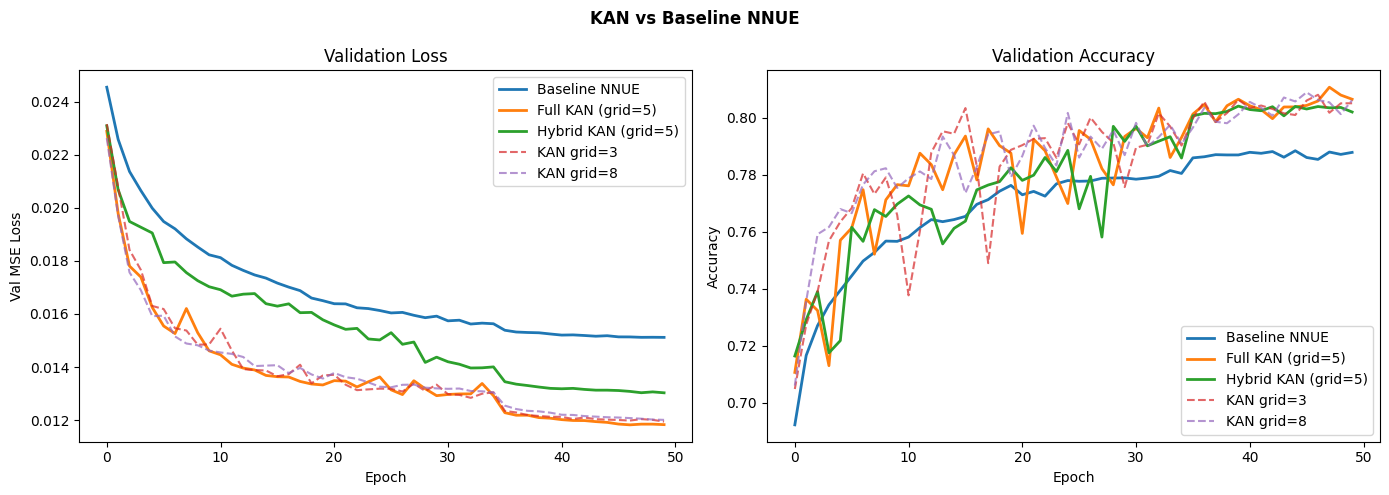

In [8]:
import matplotlib.pyplot as plt
import json

# Load baseline log from Drive
baseline_checkpointer = DriveCheckpointer('baseline')
baseline_log = baseline_checkpointer.load_log()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val loss comparison
if baseline_log:
    axes[0].plot(baseline_log['val_loss'], label='Baseline NNUE', linewidth=2)
axes[0].plot(kan_log['val_loss'], label=f'Full KAN (grid={GRID_SIZE})', linewidth=2)
axes[0].plot(hybrid_log['val_loss'], label=f'Hybrid KAN (grid={GRID_SIZE})', linewidth=2)
for gs, log in grid_sweep_logs.items():
    if gs != GRID_SIZE:  # Avoid duplicate
        axes[0].plot(log['val_loss'], label=f'KAN grid={gs}', alpha=0.7, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val MSE Loss')
axes[0].set_title('Validation Loss')
axes[0].legend()

# Val accuracy comparison
if baseline_log:
    axes[1].plot(baseline_log['val_accuracy'], label='Baseline NNUE', linewidth=2)
axes[1].plot(kan_log['val_accuracy'], label=f'Full KAN (grid={GRID_SIZE})', linewidth=2)
axes[1].plot(hybrid_log['val_accuracy'], label=f'Hybrid KAN (grid={GRID_SIZE})', linewidth=2)
for gs, log in grid_sweep_logs.items():
    if gs != GRID_SIZE:
        axes[1].plot(log['val_accuracy'], label=f'KAN grid={gs}', alpha=0.7, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()

plt.suptitle('KAN vs Baseline NNUE', fontweight='bold')
plt.tight_layout()

results_dir = Path('/content/drive/MyDrive/kanue/results')
plt.savefig(str(results_dir / 'kan_vs_baseline.png'), dpi=150)
plt.show()

In [9]:
# Summary table
print(f'{"Model":<30} {"Best Val Loss":>15} {"Best Val Acc":>15} {"Params":>12}')
print('-' * 75)

if baseline_log:
    print(f'{"Baseline NNUE":<30} {min(baseline_log["val_loss"]):>15.6f} {max(baseline_log["val_accuracy"]):>15.4f} {"~99k":>12}')

print(f'{f"Full KAN (grid={GRID_SIZE})":<30} {min(kan_log["val_loss"]):>15.6f} {max(kan_log["val_accuracy"]):>15.4f}')
print(f'{f"Hybrid KAN (grid={GRID_SIZE})":<30} {min(hybrid_log["val_loss"]):>15.6f} {max(hybrid_log["val_accuracy"]):>15.4f}')

for gs, log in sorted(grid_sweep_logs.items()):
    print(f'{f"KAN sweep grid={gs}":<30} {min(log["val_loss"]):>15.6f} {max(log["val_accuracy"]):>15.4f}')

print('\nKAN training complete. Proceed to notebook 04 for detailed analysis.')

Model                            Best Val Loss    Best Val Acc       Params
---------------------------------------------------------------------------
Baseline NNUE                         0.015118          0.7885         ~99k
Full KAN (grid=5)                     0.011818          0.8108
Hybrid KAN (grid=5)                   0.013027          0.8042
KAN sweep grid=3                      0.011941          0.8081
KAN sweep grid=5                      0.011803          0.8122
KAN sweep grid=8                      0.012006          0.8090

KAN training complete. Proceed to notebook 04 for detailed analysis.
